In [3]:
!python -m venv 3rfold_env
!3rfold_env/bin/python -m pip install ipykernel
!3rfold_env/bin/python -m ipykernel install --user --name=3rfold_env --display-name "Python (3rfold_env)"

'3rfold_env' is not recognized as an internal or external command,
operable program or batch file.
'3rfold_env' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
!pip install -r requirements.txt

  Using cached torch-2.10.0-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached faiss_cpu-1.13.2-cp314-cp314-win_amd64.whl.metadata (7.6 kB)
  Using cached biopython-1.86-cp314-cp314-win_amd64.whl.metadata (13 kB)
  Using cached viennarna-2.7.2-cp314-cp314-win_amd64.whl.metadata (14 kB)
  Using cached datasets-4.7.0-py3-none-any.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached rna_fm-0.2.2-py3-none-any.whl.metadata (10 kB)
  Using cached torchvision-0.25.0-cp314-cp314-win_amd64.whl.metadata (5.4 kB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cach

Run 3RFold with defined configuration

In [7]:
from run_3RFold import main

main(config_path="configs/default.yaml")

Device: cpu
Building dataset...
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset size: 1600
Initializing pretrained embedder...
Building / loading embeddings...
Saved embeddings to kb_embeddings_rnafm_len256.pt
KB embeddings shape: torch.Size([1600, 640])
Building FAISS index...
Query family: 16S_rRNA
Query embedding shape: torch.Size([1, 640])
Neighbor families: ['16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA']
Number of neighbor structures used: 7
{'query_family': '16S_rRNA', 'neighbor_families': ['16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA', '16S_rRNA'], 'pred_structure': '.(((((...............................(((((..(((((((((....)))))))))...)))))....((((((((........)))))))).....((....))...................(((....(((..((((((((.......)))))))))))......)))..((((((((....))))...))))....(((((((........))))))).((((....))))......((((.(......(((...(((


Map: 100%|██████████| 37149/37149 [00:02<00:00, 13086.00 examples/s]

Map: 100%|██████████| 3975/3975 [00:00<00:00, 4040.60 examples/s]

Map: 100%|██████████| 25425/25425 [00:01<00:00, 13164.10 examples/s]

Map: 100%|██████████| 28105/28105 [00:02<00:00, 12727.23 examples/s]

Embedding KB: 100%|██████████| 400/400 [05:50<00:00,  1.14it/s]


# Run benchmark and save results

In [ ]:
from experiments.run_benchmark import main
main()

/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Downloading: "https://proj.cse.cuhk.edu.hk/rnafm/api/download?filename=RNA-FM_pretrained.pth" to /root/.cache/torch/hub/checkpoints/RNA-FM_pretrained.pth
100% 1.11G/1.11G [12:08<00:00, 1.64MB/s]
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

=== Benchmark summary ===
                  method   n   f1_mean  ...  ppv_mean  purity_mean  runtime_mean
0  rnafm_faiss_guided_k5  50  0.576590  ...  0.621680        0.864      1.005329
1            vienna_only  50  0.416877  ...  0.40

# Run ablation and save results

In [9]:
from experiments.run_ablation import main
main()

G:\.Datasets\Final-3R-Fold\.venv\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
Traceback (most recent call last):
  File "G:\.Datasets\Final-3R-Fold\experiments\run_ablation.py", line 131, in <module>
    main()
    ~~~~^^
  File "G:\.Datasets\Final-3R-Fold\experiments\run_ablation.py", line 88, in main
    df = run_benchmark(
        dataset=dataset,
    ...<10 lines>...
        cache_path="results/kb_embeddings_rnafm_len256.pt",
    )
  File "G:\.Datasets\Final-3R-Fold\evaluation\benchmark.py", line 211, in run_benchmark
    row = run_single_query(
        query_item=query_item,
    ...<7 lines>...
        guidance_mode=guidance_mode,
    )
  File "G:\.Datasets\Final-3R-Fold\evaluation\b

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})

Running: vienna_only

Running: rnafm_faiss_no_guidance_k5
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...


G:\.Datasets\Final-3R-Fold\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
G:\.Datasets\Final-3R-Fold\.venv\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})

Running: vienna_only

Running: rnafm_faiss_no_guidance_k5
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k1
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k3
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k5
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k7
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_guided_k14
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: rnafm_faiss_template_guided_k5
Loading cached embeddings from results/kb_embeddings_rnafm_len256.pt...

Running: oracle_guided_k5

=== Ablation summary ===
                           method   n   f1_mean    f1_std

# Plotting results

In [10]:
from visualisation.performance_plots import *
from visualisation.family_plots import *
from visualisation.retrieval_plots import *
from visualisation.improvement_plots import *


plot_f1_by_method("results/ablation_results.csv")
plot_k_sweep("results/ablation_results.csv")
plot_violin_f1("results/ablation_results.csv")
plot_family_f1("results/ablation_results.csv")
plot_purity_vs_f1("results/ablation_results.csv")
plot_similarity_vs_f1("results/ablation_results.csv")
plot_improvement_over_baseline("results/ablation_results.csv")
plot_improvement_vs_purity("results/ablation_results.csv")

plot_f1_by_method("results/ablation_results.csv")
plot_k_sweep("results/ablation_results.csv")
plot_violin_f1("results/ablation_results.csv")
plot_family_f1("results/ablation_results.csv")
plot_purity_vs_f1("results/ablation_results.csv")
plot_similarity_vs_f1("results/ablation_results.csv")

plot_f1_by_method("results/ablation_results.csv")
plot_k_sweep("results/ablation_results.csv")
plot_violin_f1("results/ablation_results.csv")

plot_family_f1("results/ablation_results.csv")

plot_purity_vs_f1("results/ablation_results.csv")
plot_similarity_vs_f1("results/ablation_results.csv")

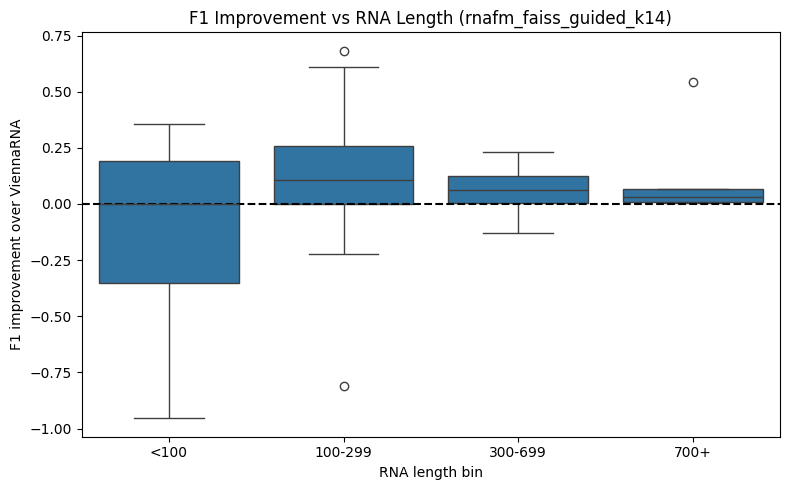

In [11]:
import importlib
import visualisation.length_plots as lp

importlib.reload(lp)

lp.plot_improvement_vs_length("results/ablation_results.csv")

# Run LOFO benchmark

In [12]:
from experiments.run_lofo_benchmark import run_lofo
run_lofo()

Building dataset...
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset built: 1600
Families: ['16S_rRNA', '5S_rRNA', 'RNaseP', 'RfamFamily', 'SRP', 'group_I_intron', 'tRNA', 'tmRNA']
Loading full cached embeddings from results/kb_embeddings_rnafm_len256_full.pt...
All embeddings shape: torch.Size([1600, 640])

LOFO: 16S_rRNA
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: 5S_rRNA
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: RNaseP
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: RfamFamily
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: SRP
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: group_I_intron
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([1400, 640])

LOFO: tRNA
KB size: 1400 Test size: 200
KB embedding shape: torch.Size([

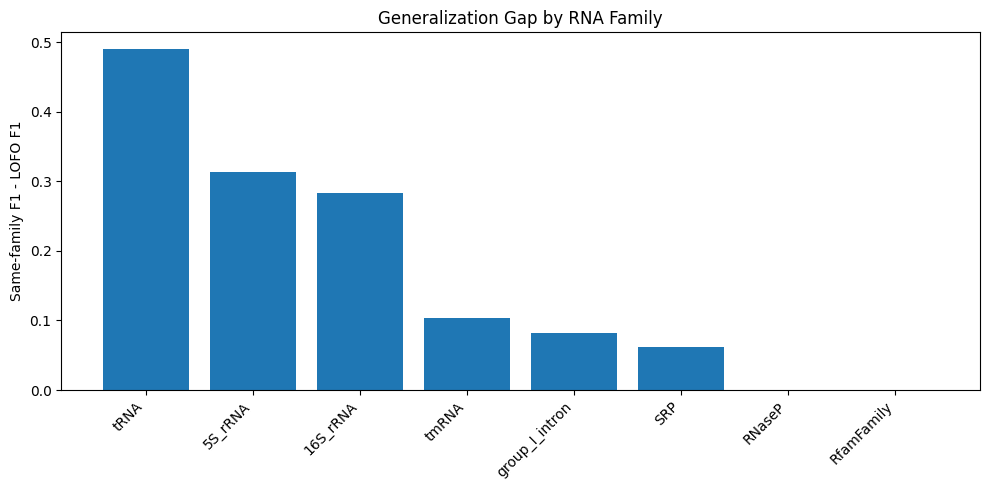

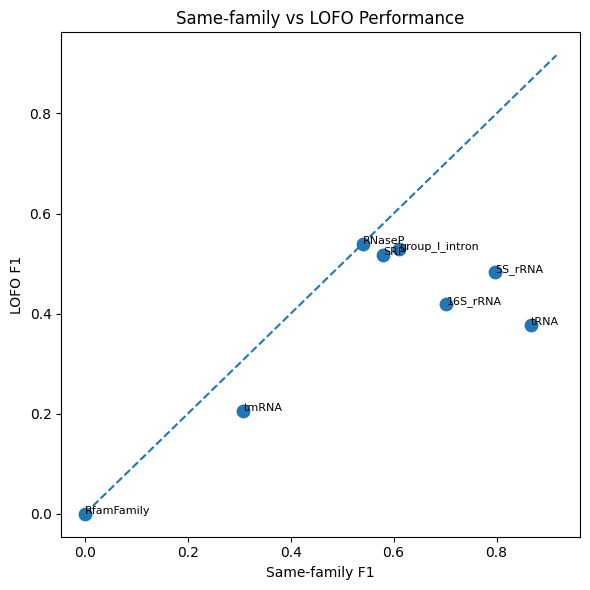

In [13]:
from evaluation.generalization_gap import compute_generalization_gap
from visualisation.generalization_plots import plot_generalization_gap, plot_same_vs_lofo

compute_generalization_gap()
plot_generalization_gap()
plot_same_vs_lofo()

In [14]:
from evaluation.failure_analysis import retrieval_failure_analysis
failure_df = retrieval_failure_analysis()
print(failure_df.head())

                                 query_id      family  length  \
0                       tRNA-tdbD00005436        tRNA      75   
1     RfamFamily_URS0000D68DE1_12908/1-49  RfamFamily      49   
2    RfamFamily_URS0000D6C504_12908/1-170  RfamFamily     170   
3  SRP-long_bacterial-Clos.ther._CP000568         SRP     175   
4       RfamFamily_AAIY01141103.1/124-267  RfamFamily     144   

                   method retrieval_type  use_guidance guidance_mode  use_dsr  \
0  rnafm_faiss_guided_k14          faiss             1     consensus        0   
1  rnafm_faiss_guided_k14          faiss             1     consensus        0   
2  rnafm_faiss_guided_k14          faiss             1     consensus        0   
3  rnafm_faiss_guided_k14          faiss             1     consensus        0   
4  rnafm_faiss_guided_k14          faiss             1     consensus        0   

    k                                  neighbor_families  ...   f1  \
0  14  tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|tRNA|

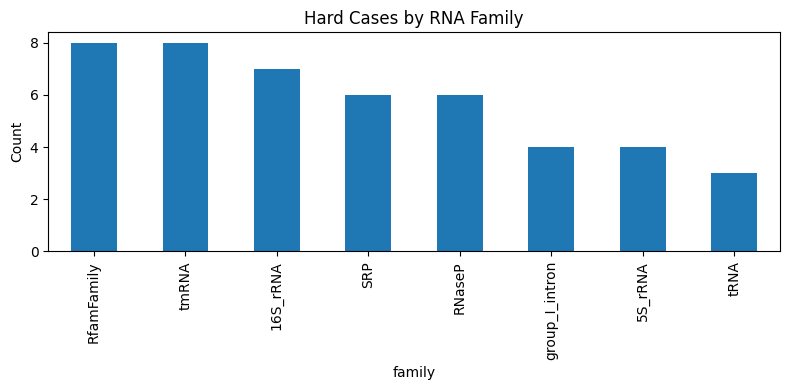

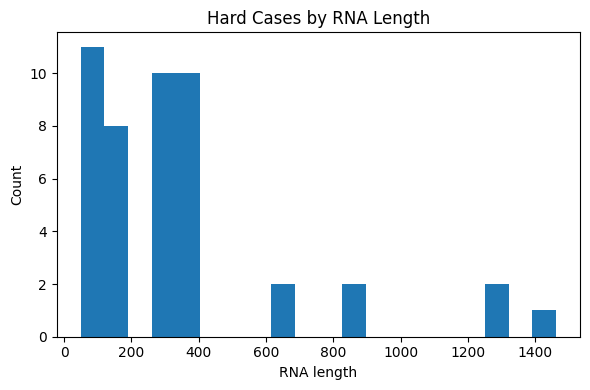

In [15]:
from visualisation.hard_case_plots import plot_hard_cases_by_family, plot_hard_cases_by_length

plot_hard_cases_by_family()
plot_hard_cases_by_length()

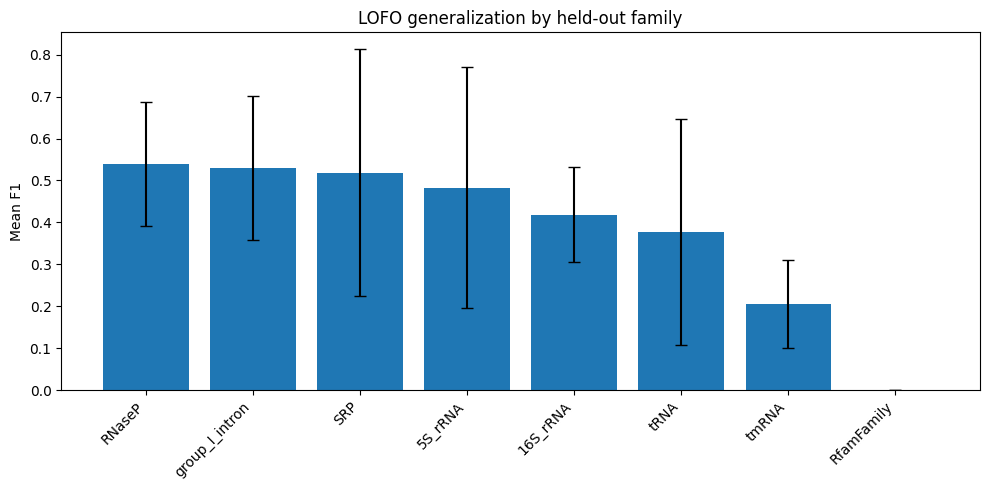

In [16]:
from visualisation.lofo_plots import plot_lofo_f1
plot_lofo_f1()

# Run umap embedding

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


G:\.Datasets\Final-3R-Fold\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


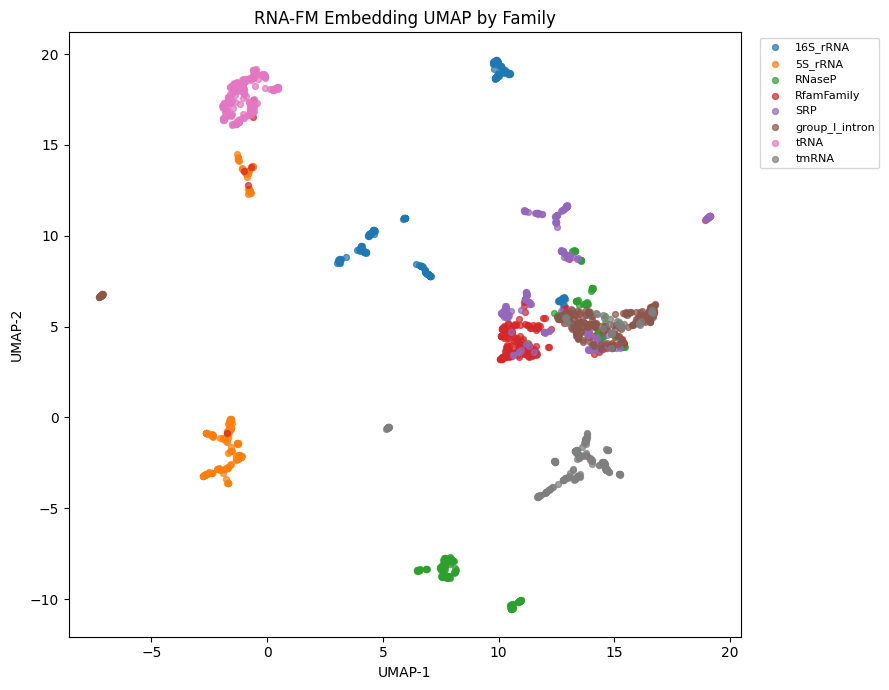

In [17]:
from experiments.run_embedding_umap import main
main()

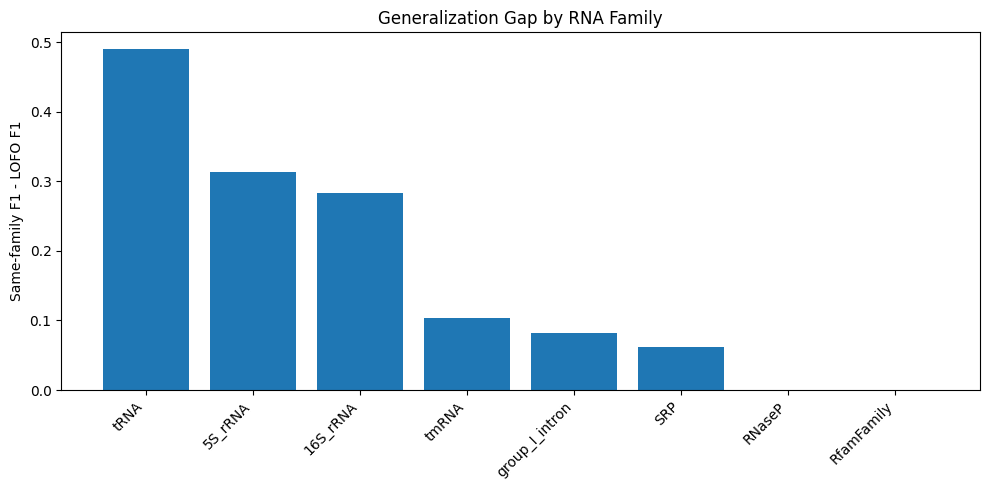

In [18]:
from evaluation.generalization_gap import compute_generalization_gap
from visualisation.generalization_plots import plot_generalization_gap

compute_generalization_gap()
plot_generalization_gap()

Run DSR Ablation

In [19]:
from experiments.run_dsr_ablation import main
main()

PROJECT_ROOT: G:\.Datasets\Final-3R-Fold
RESULTS_DIR: G:\.Datasets\Final-3R-Fold\results
OUTPUT CSV: G:\.Datasets\Final-3R-Fold\results\dsr_ablation.csv
EMBEDDINGS PATH: G:\.Datasets\Final-3R-Fold\results\kb_embeddings_rnafm_len256_full.pt
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Running DSR query 1/50
Epoch 1/20 Loss 0.2476
Epoch 20/20 Loss 0.5731
Running DSR query 2/50
Epoch 1/20 Loss 0.2497
Epoch 20/20 Loss 0.5512
Running DSR query 3/50
Epoch 1/20 Loss 0.2456
Epoch 20/20 Loss 0.5504
Running DSR query 4/50
Epoch 1/20 Loss 0.2491
Epoch 20/20 Loss 0.5524
Running DSR query 5/50
Epoch 1/20 Loss 0.2523
Epoch 20/20 Loss 0.5379
Running DSR query 6/50
Epoch 1/20 Loss 0.2476
Epoch 20/20 Loss 0.5780
Running DSR query 7/50
Epoch 1/20 Loss 0.2482
Epoch 20/20 Loss 0.5417
Running DSR query 8/50
Epoch 1/20 Loss 0.2426
Epoch 20/20 Loss 0.5562
Running DSR query 9/50
Epoch 1/20 Loss 0.2429
Epoch 20/20 Loss 0.5738
Runni

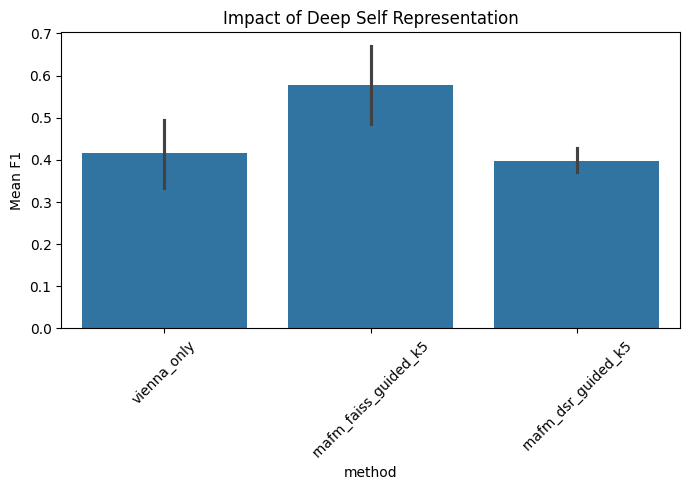

In [20]:
from visualisation.dsr_plots import plot_dsr_comparison
plot_dsr_comparison()

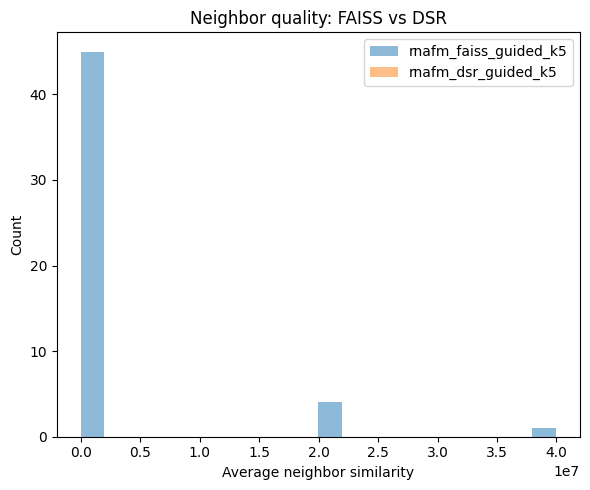

In [21]:
from visualisation.dsr_retrieval_plots import plot_neighbor_quality
plot_neighbor_quality()

# Run DSR global Ablation

In [22]:
from experiments.run_dsr_global_ablation import main
main()

PROJECT_ROOT: G:\.Datasets\Final-3R-Fold
RESULTS_DIR: G:\.Datasets\Final-3R-Fold\results
OUTPUT CSV: G:\.Datasets\Final-3R-Fold\results\dsr_global_ablation.csv
EMBEDDINGS PATH: G:\.Datasets\Final-3R-Fold\results\kb_embeddings_rnafm_len256_full.pt
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'structure'],
    num_rows: 1600
})
Training global DSR once on all embeddings...
Epoch 1/20 Loss 0.2524
Epoch 20/20 Loss 0.5429
Saved DSR matrix to: G:\.Datasets\Final-3R-Fold\results\dsr_global_Z.pt
Evaluating query 1/50
Evaluating query 2/50
Evaluating query 3/50
Evaluating query 4/50
Evaluating query 5/50
Evaluating query 6/50
Evaluating query 7/50
Evaluating query 8/50
Evaluating query 9/50
Evaluating query 10/50
Evaluating query 11/50
Evaluating query 12/50
Evaluating query 13/50
Evaluating query 14/50
Evaluating query 15/50
Evaluating query 16/50
Evaluating query 17/50
Evaluating query 18/50
Evaluating query 19/50
Evaluating query 20/50
Evaluating query 21/50
Ev

In [23]:
from experiments.run_dsr_global_all import main
main()

PROJECT_ROOT: G:\.Datasets\Final-3R-Fold
RESULTS_DIR: G:\.Datasets\Final-3R-Fold\results
OUTPUT CSV: G:\.Datasets\Final-3R-Fold\results\dsr_global_all_results.csv
Z PATH: G:\.Datasets\Final-3R-Fold\results\dsr_global_Z.pt
EMBEDDINGS PATH: G:\.Datasets\Final-3R-Fold\results\kb_embeddings_rnafm_len256_full.pt
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset size: 1600
Embeddings shape: torch.Size([1600, 640])
Training global DSR on all embeddings...
Epoch 1/80 Loss 0.2465
Epoch 80/80 Loss 0.3941
Saved DSR matrix to: G:\.Datasets\Final-3R-Fold\results\dsr_global_Z.pt
Evaluating query 1/1600
Evaluating query 100/1600
Evaluating query 200/1600
Evaluating query 300/1600
Evaluating query 400/1600
Evaluating query 500/1600
Evaluating query 600/1600
Evaluating query 700/1600
Evaluating query 800/1600
Evaluating query 900/1600
Evaluating query 1000/1600
Evaluating query 1100/1600
Evaluating query 1200/1600
Evalua

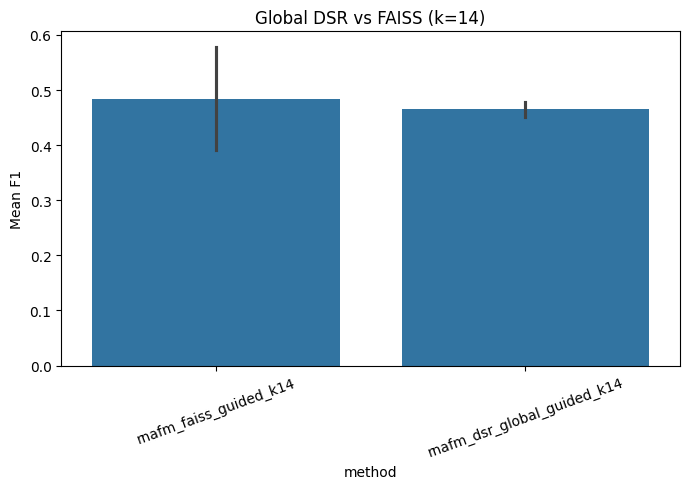

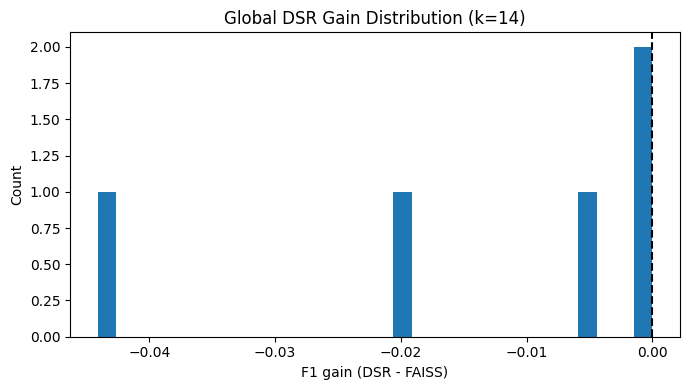

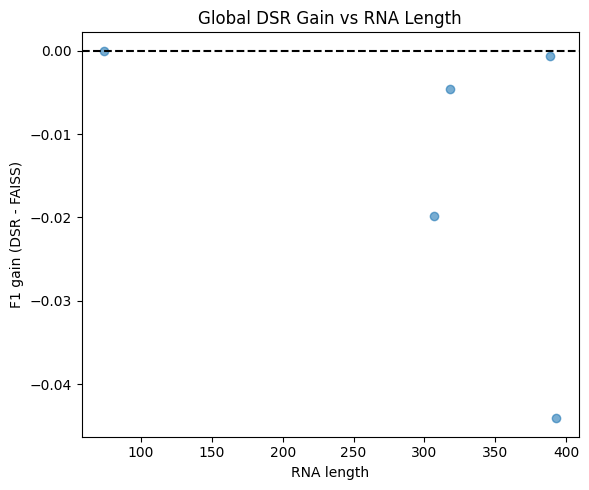

In [24]:
from visualisation.dsr_all_plots import (
    plot_dsr_all_vs_faiss_k14,
    plot_dsr_all_gain_distribution,
    plot_dsr_all_gain_vs_length,
)

plot_dsr_all_vs_faiss_k14()
plot_dsr_all_gain_distribution()
plot_dsr_all_gain_vs_length()

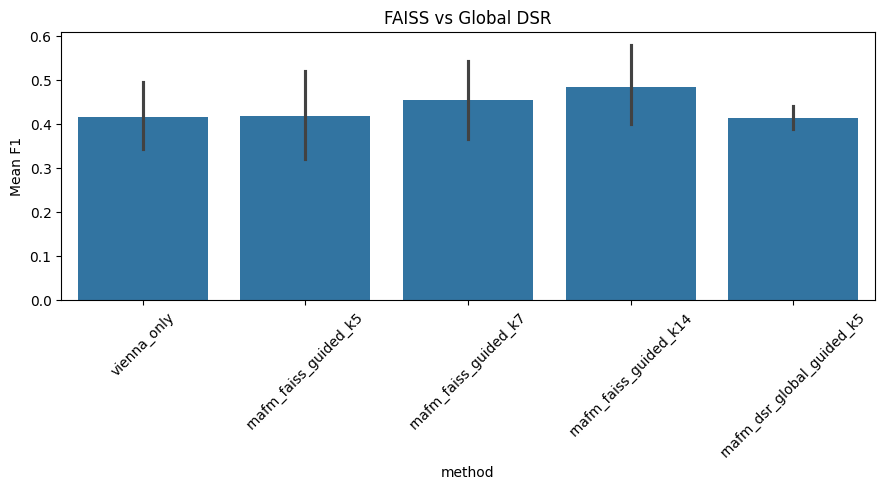

In [25]:
from visualisation.dsr_global_plots import plot_dsr_global_comparison
plot_dsr_global_comparison()

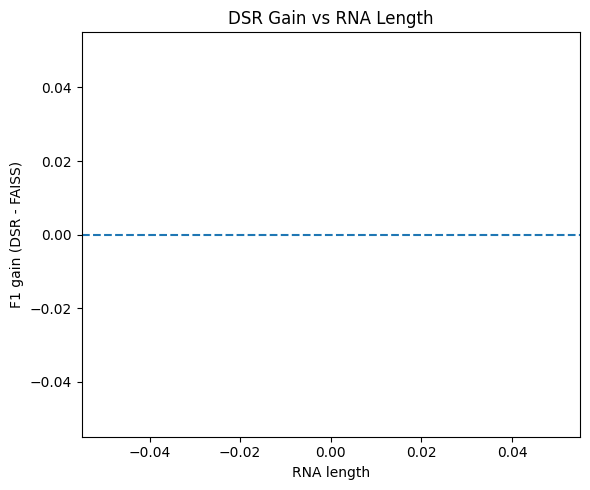

In [26]:
from visualisation.dsr_global_plots import plot_dsr_gain_vs_length
plot_dsr_gain_vs_length()

In [27]:
from experiments.run_dsr_faiss_hybrid import main
main()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset size: 1600
Embeddings shape: torch.Size([1600, 640])
Training DSR once on RNA-FM embeddings...
Epoch 1/80 Loss 0.2466
Epoch 80/80 Loss 0.3359
Saved latent embeddings to: G:\.Datasets\Final-3R-Fold\results\dsr_latent_embeddings.pt
Building FAISS on DSR latent embeddings...
Evaluating query 1/1600
Evaluating query 100/1600
Evaluating query 200/1600
Evaluating query 300/1600
Evaluating query 400/1600
Evaluating query 500/1600
Evaluating query 600/1600
Evaluating query 700/1600
Evaluating query 800/1600
Evaluating query 900/1600
Evaluating query 1000/1600
Evaluating query 1100/1600
Evaluating query 1200/1600
Evaluating query 1300/1600
Evaluating query 1400/1600
Evaluating query 1500/1600
Evaluating query 1600/1600

Saved:
G:\.Datasets\Final-3R-Fold\results\dsr_faiss_hybrid_results.csv
G:\.Datasets\Final-3R-Fold\results\dsr_faiss_hybrid_summary.csv

Summary:
 

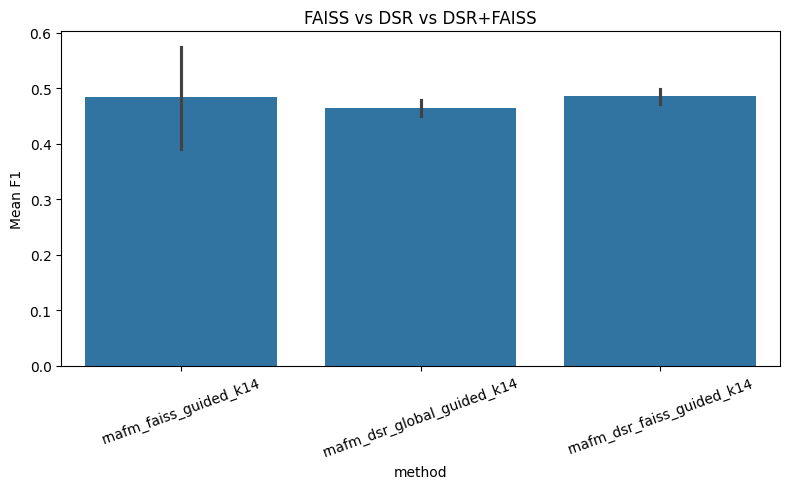

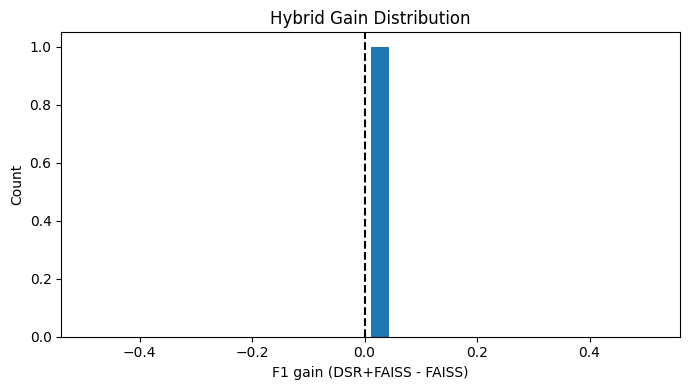

In [28]:
from visualisation.dsr_hybrid_plots import (
    plot_dsr_hybrid_comparison,
    plot_dsr_hybrid_gain_distribution,
)

plot_dsr_hybrid_comparison()
plot_dsr_hybrid_gain_distribution()

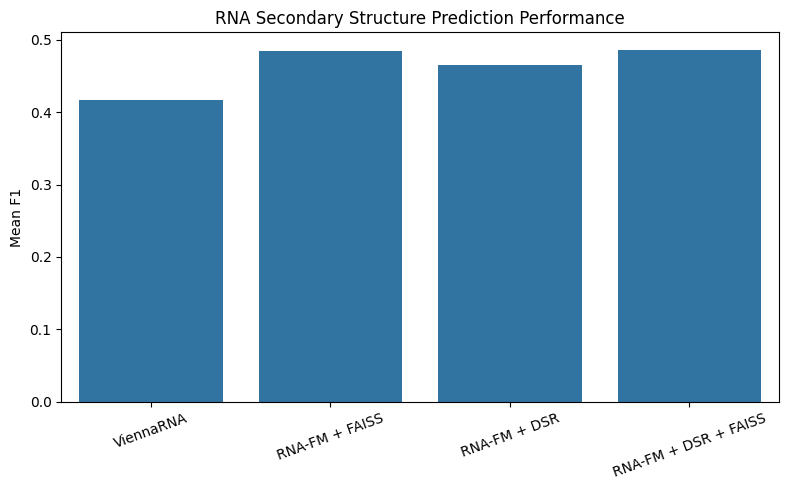

                 method        f1
0             ViennaRNA  0.416877
1        RNA-FM + FAISS  0.484177
2          RNA-FM + DSR  0.464926
3  RNA-FM + DSR + FAISS  0.485821


In [29]:
from visualisation.final_model_comparison import plot_final_model_comparison

plot_final_model_comparison()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


G:\.Datasets\Final-3R-Fold\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


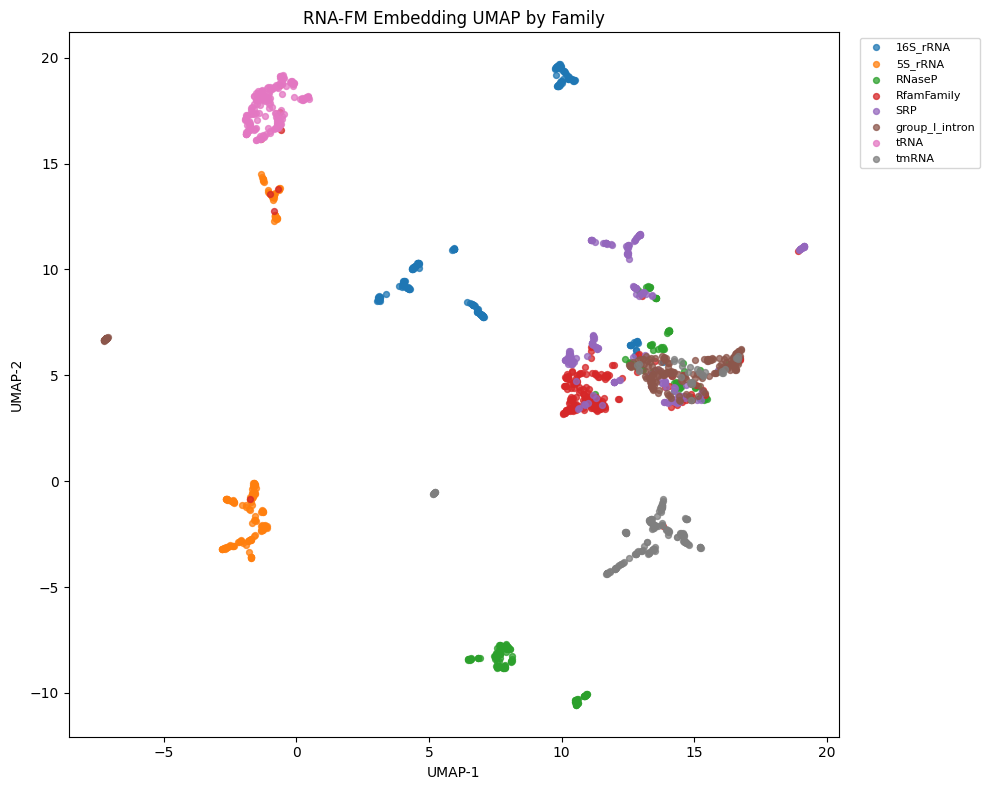

In [30]:
from visualisation.embedding_family_umap import plot_embedding_family_umap
plot_embedding_family_umap()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


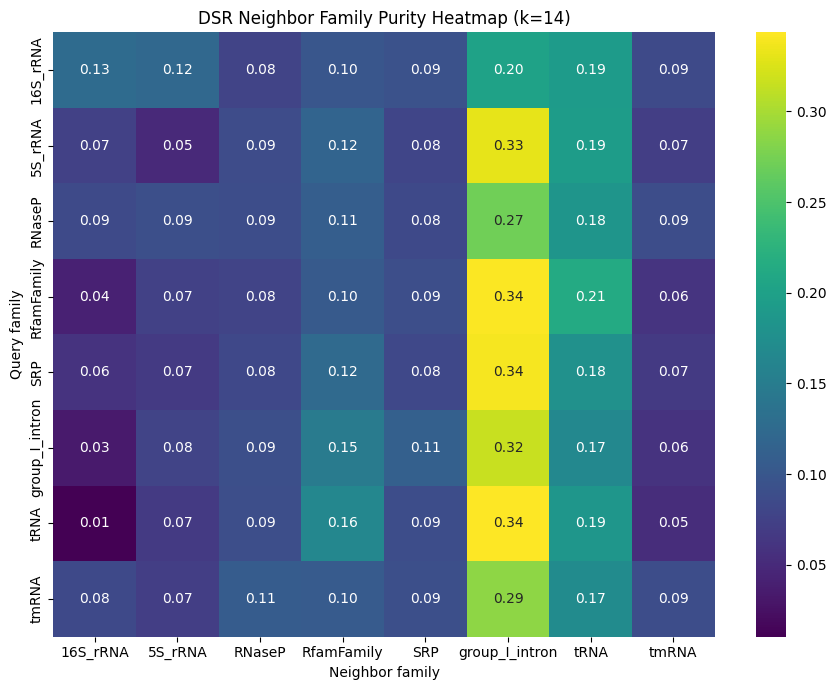

In [31]:
from visualisation.dsr_cluster_purity import plot_dsr_cluster_purity_heatmap
plot_dsr_cluster_purity_heatmap()

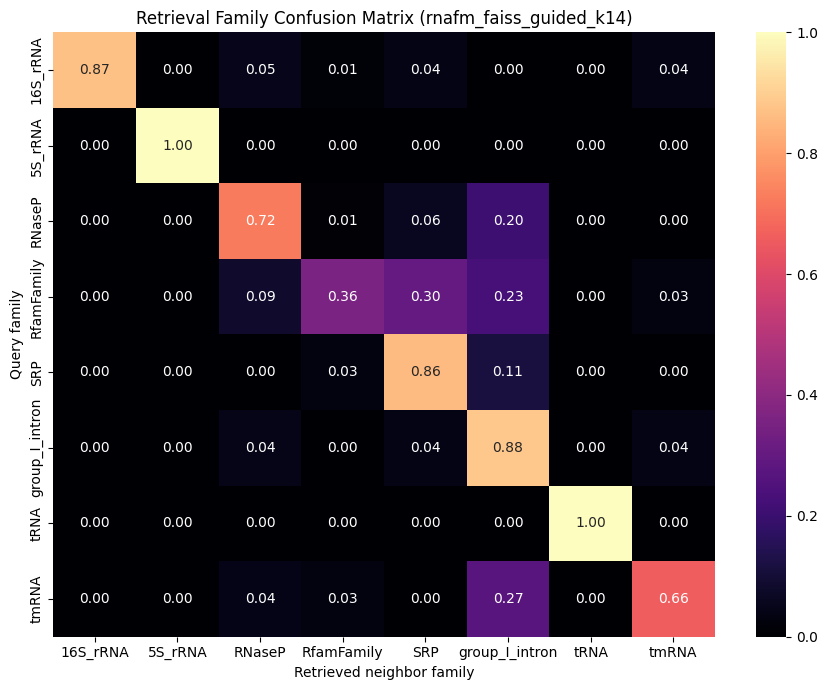

In [32]:
from visualisation.retrieval_family_confusion import plot_retrieval_family_confusion
plot_retrieval_family_confusion()

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


G:\.Datasets\Final-3R-Fold\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


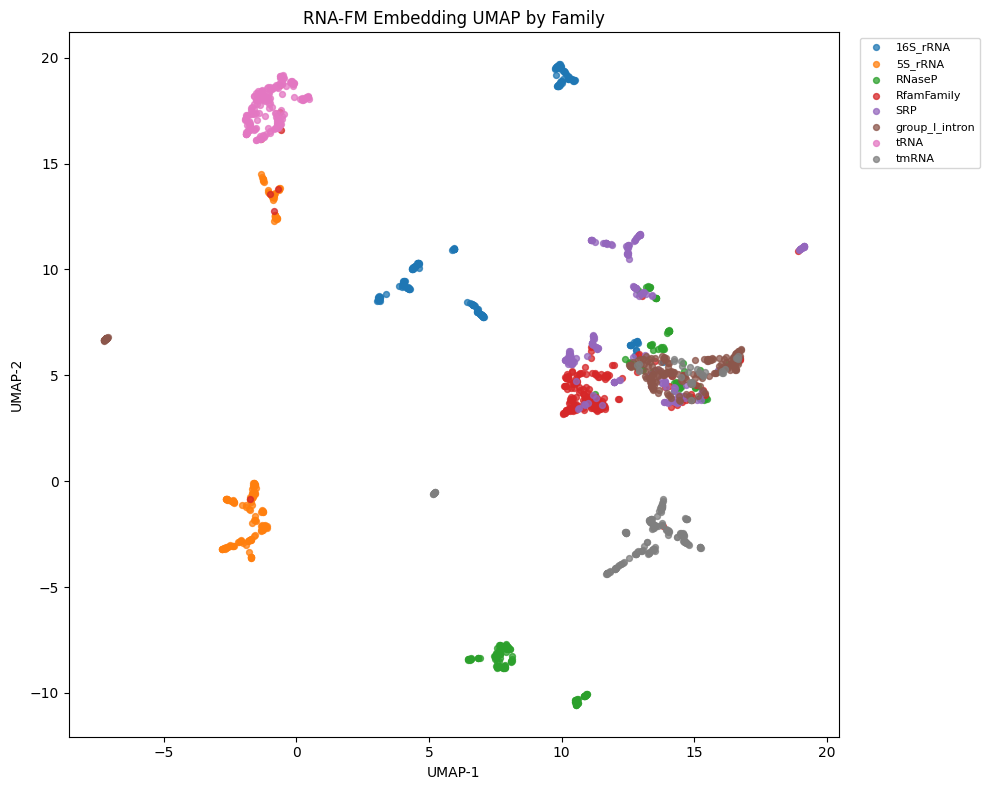

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


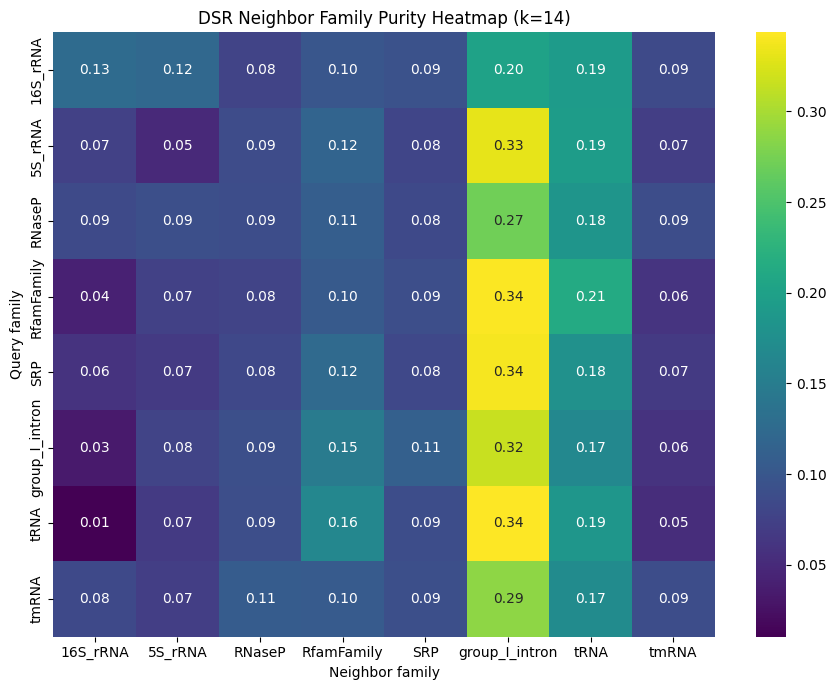

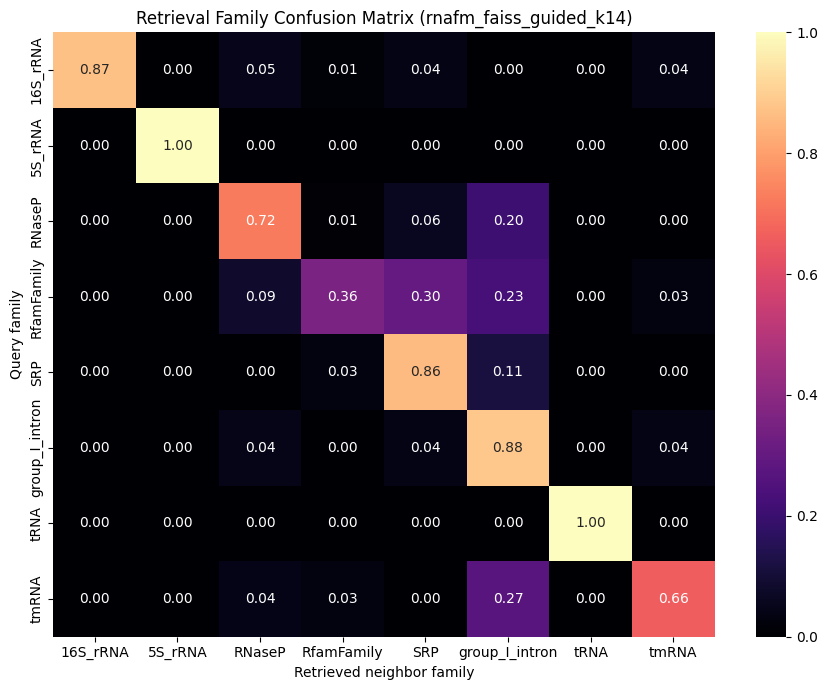

In [33]:
from visualisation.embedding_family_umap import plot_embedding_family_umap
from visualisation.dsr_cluster_purity import plot_dsr_cluster_purity_heatmap
from visualisation.retrieval_family_confusion import plot_retrieval_family_confusion

plot_embedding_family_umap()
plot_dsr_cluster_purity_heatmap()
plot_retrieval_family_confusion()

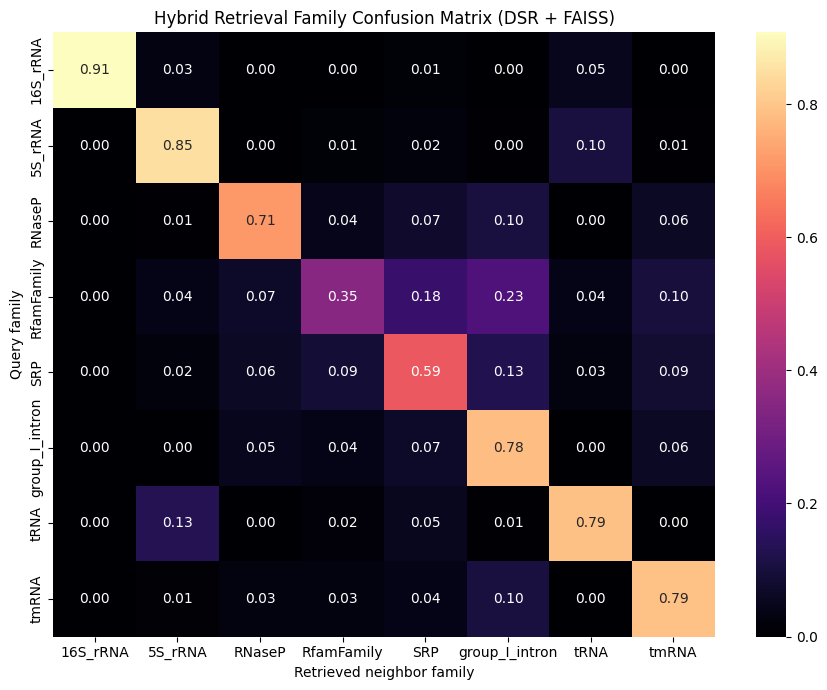

In [34]:
from visualisation.hybrid_family_confusion import plot_hybrid_family_confusion

plot_hybrid_family_confusion()

          case_type                         query_id family  length  \
0  best_improvement  tmRNA-Bloc.flor._BX248583_1-393  tmRNA     393   
0      typical_case  tmRNA-Bloc.flor._BX248583_1-393  tmRNA     393   
0        worst_case  tmRNA-Bloc.flor._BX248583_1-393  tmRNA     393   

   f1_baseline  f1_method      gain  
0     0.165138   0.228856  0.063718  
0     0.165138   0.228856  0.063718  
0     0.165138   0.228856  0.063718  


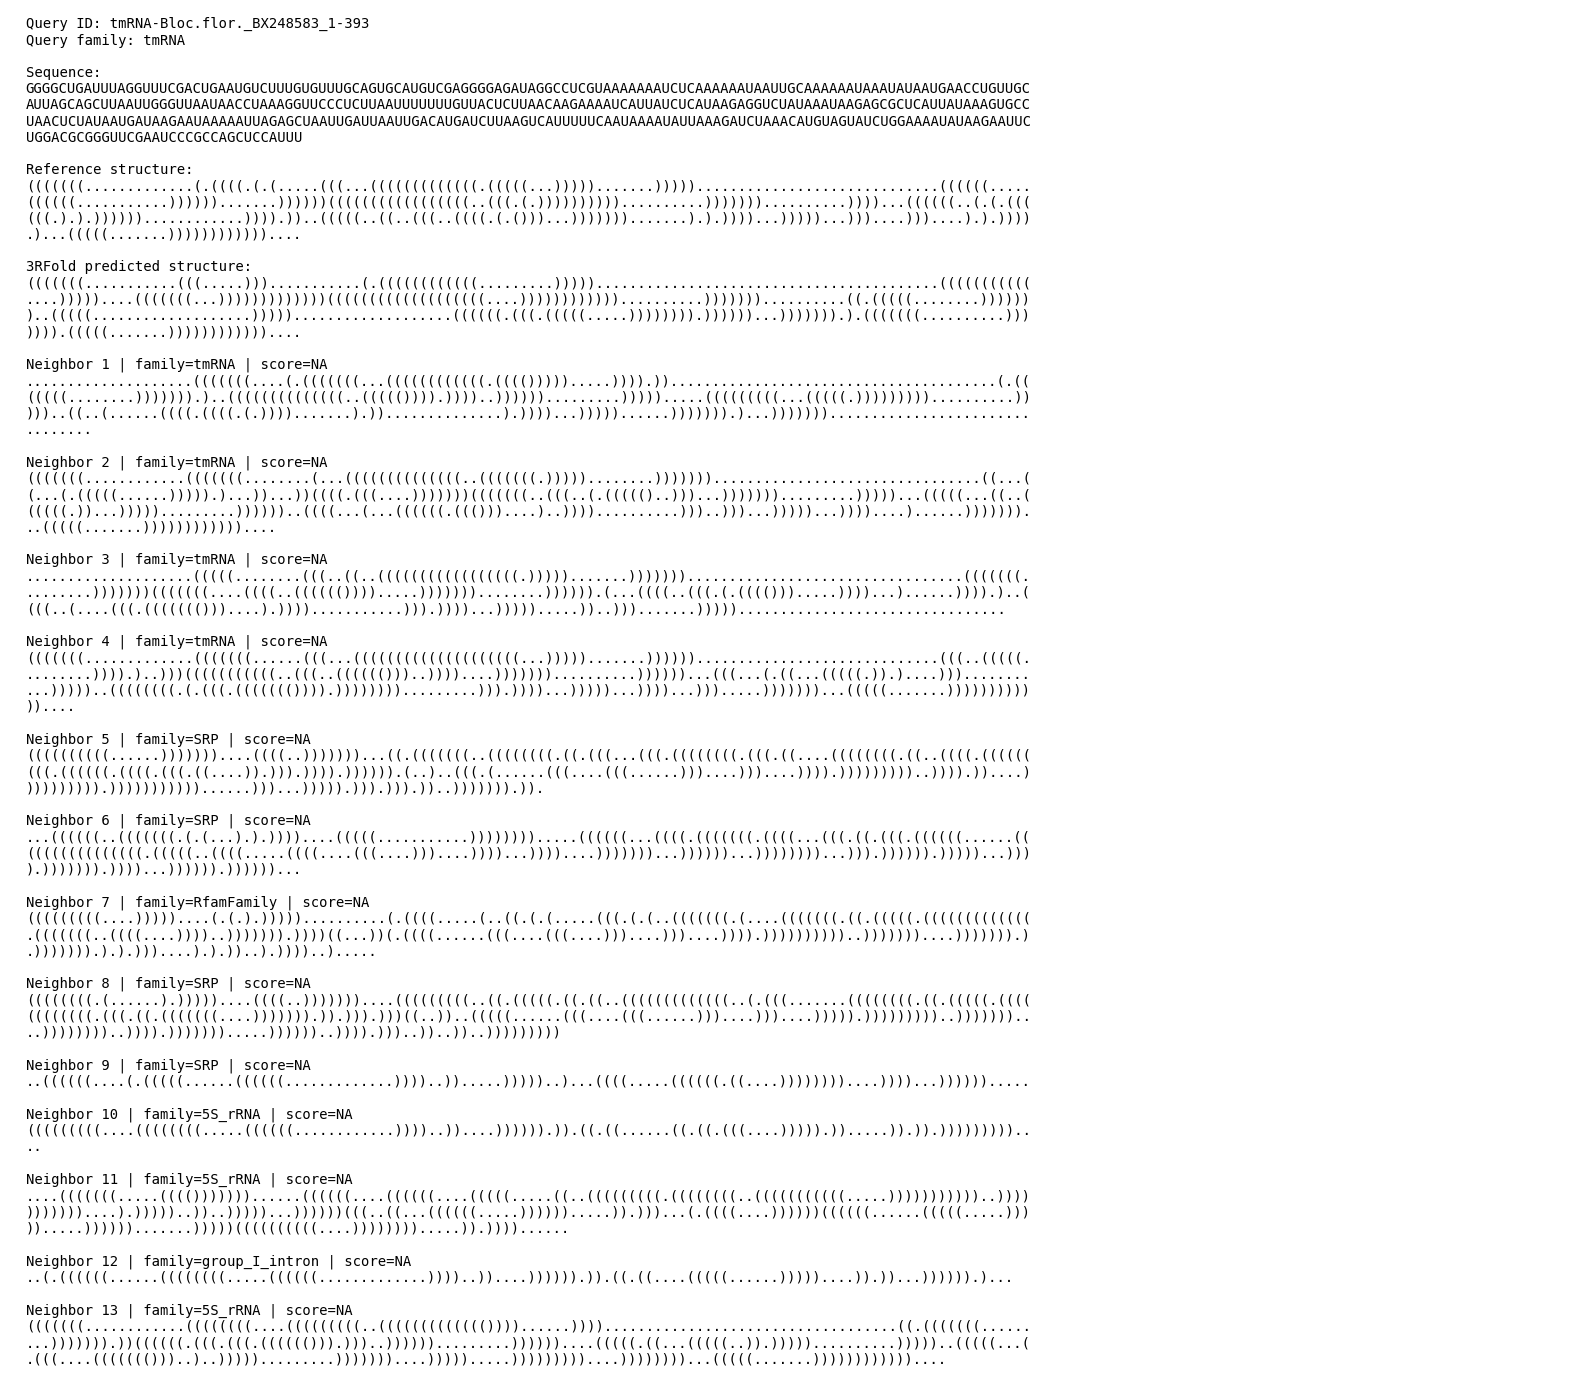

Saved: G:\.Datasets\Final-3R-Fold\results\plots\case_studies\best_improvement_tmRNA-Bloc.flor._BX248583_1-393.png


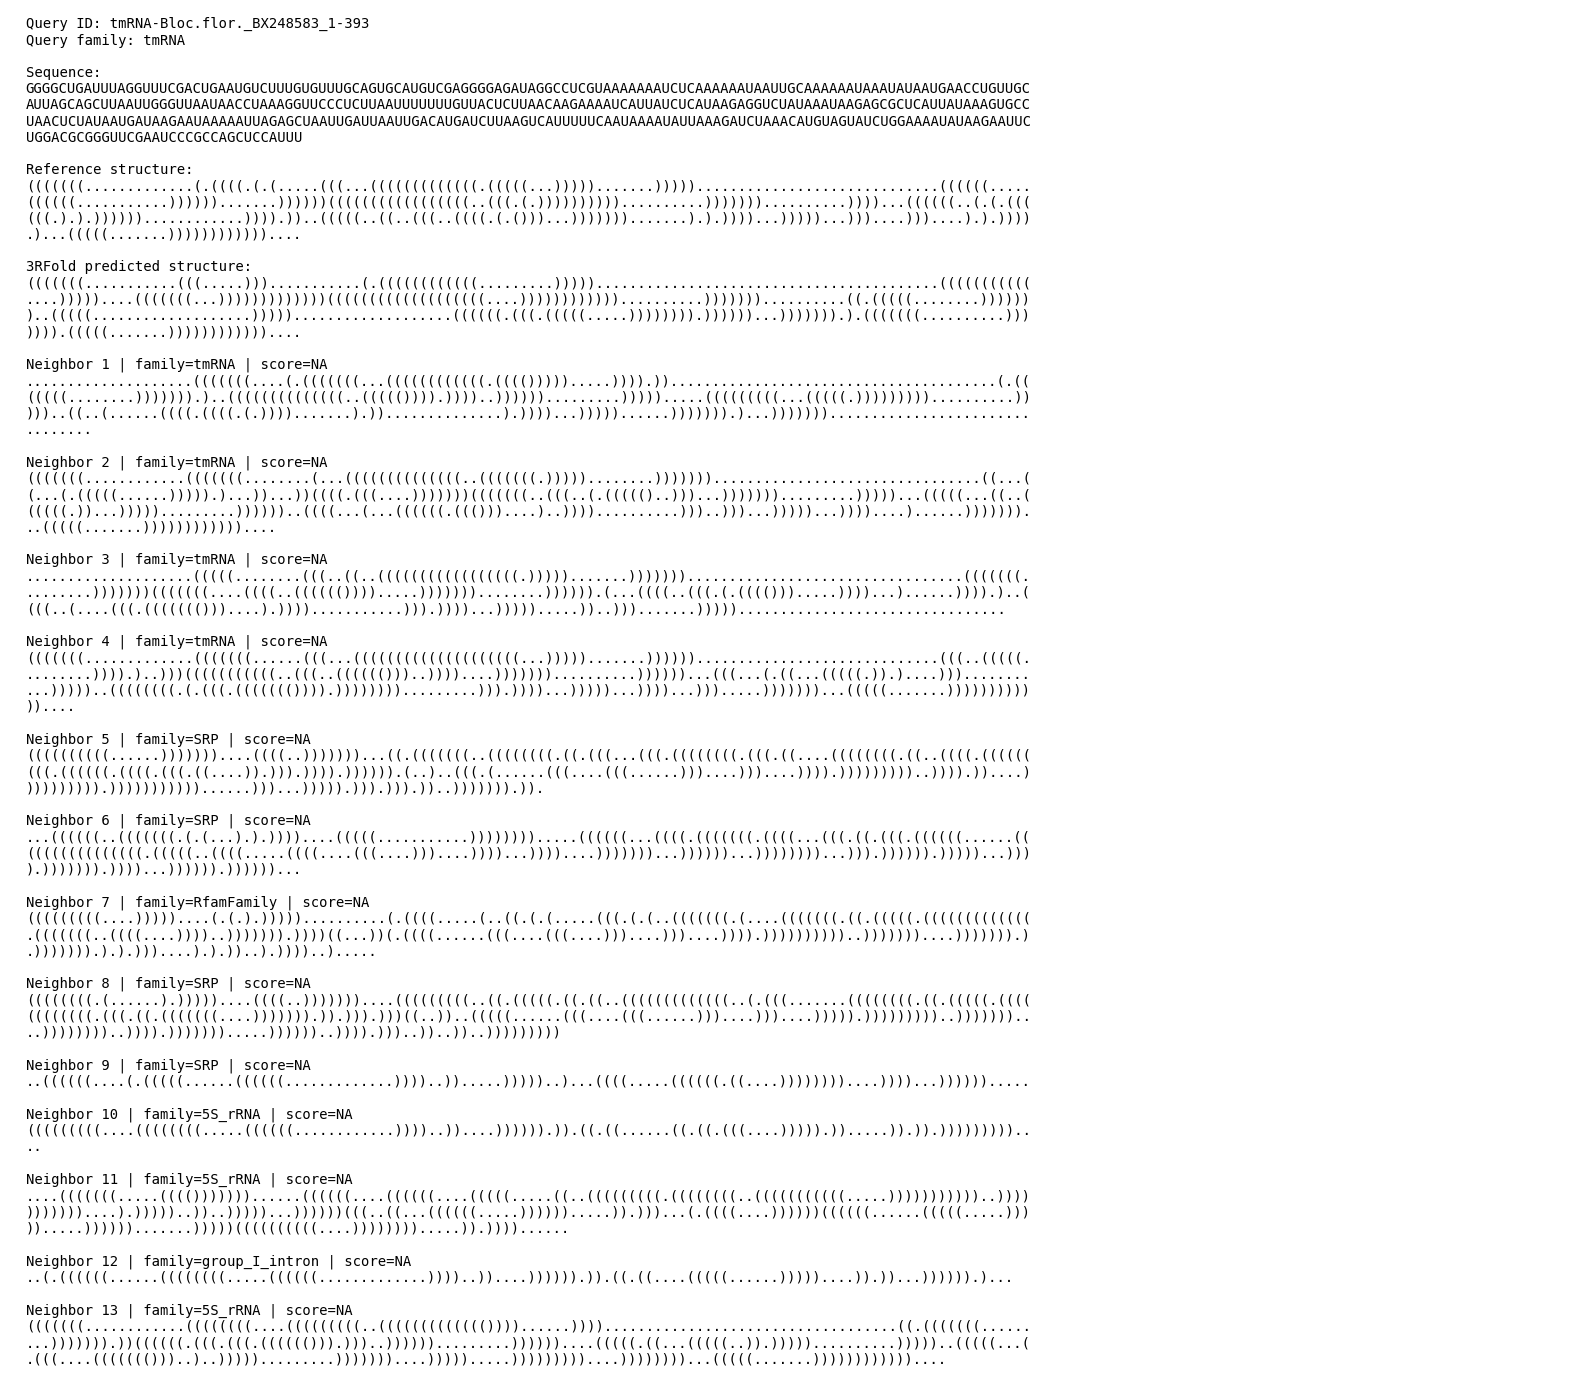

Saved: G:\.Datasets\Final-3R-Fold\results\plots\case_studies\typical_case_tmRNA-Bloc.flor._BX248583_1-393.png


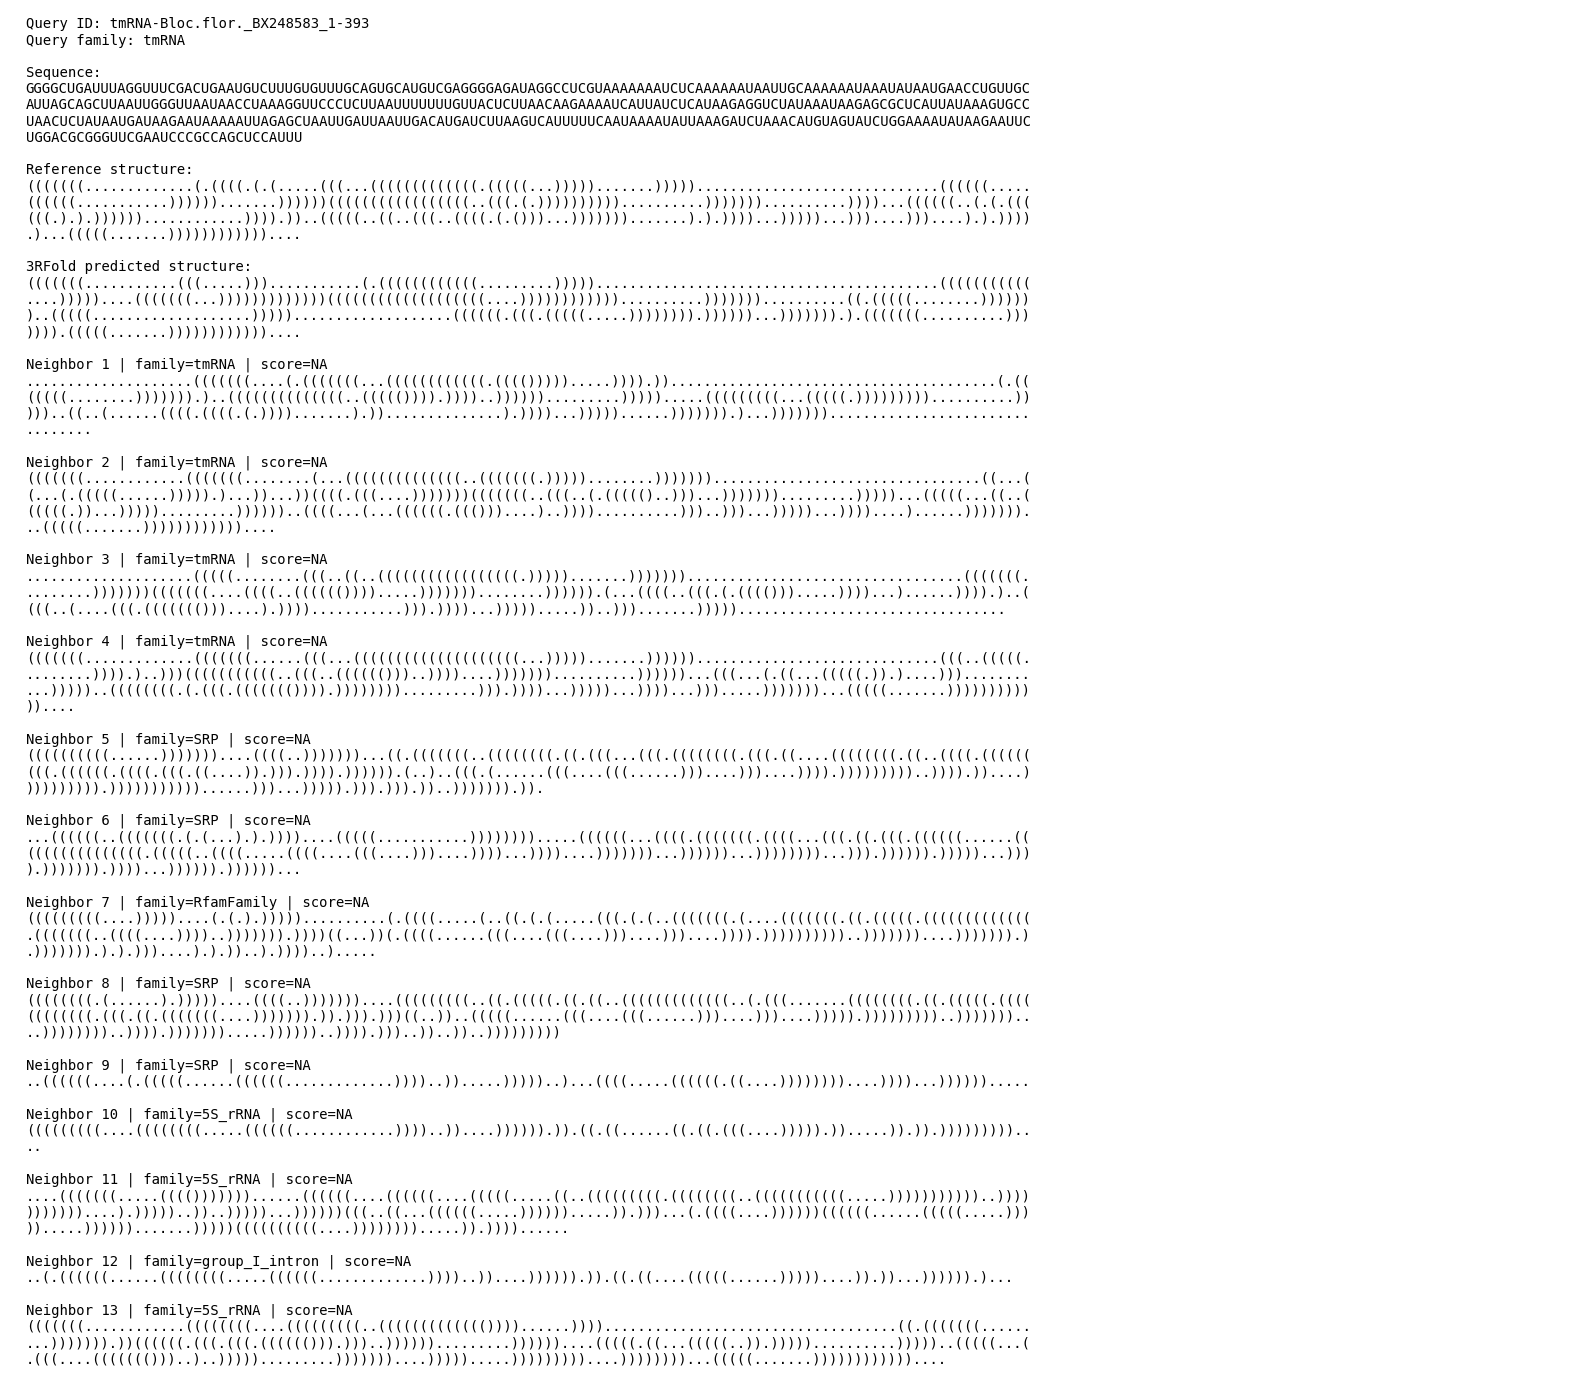

Saved: G:\.Datasets\Final-3R-Fold\results\plots\case_studies\worst_case_tmRNA-Bloc.flor._BX248583_1-393.png


In [35]:
from experiments.generate_case_studies import main
main()

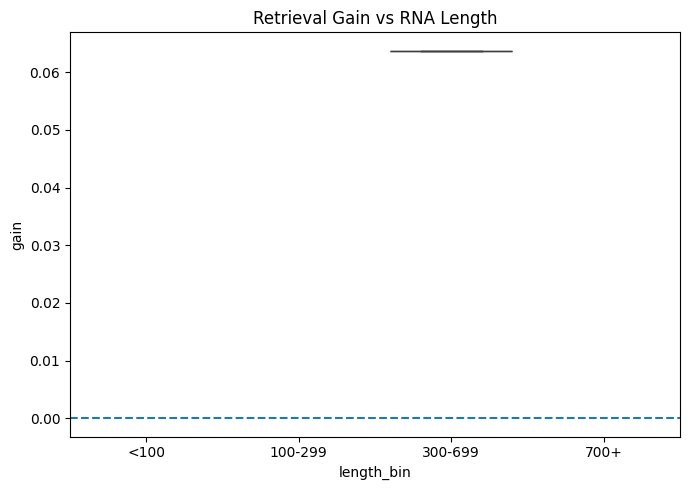

In [36]:
from visualisation.gain_vs_length import plot_gain_vs_length

plot_gain_vs_length()

In [37]:
import importlib

import visualisation.rna_radar_plot as rrp
import visualisation.rna_representation_matrix as rrm
import visualisation.rna_retrieval_graph as rrg
import visualisation.rna_tsne_embeddings as rte
import visualisation.similarity_vs_accuracy as sva

importlib.reload(rrp)
importlib.reload(rrm)
importlib.reload(rrg)
importlib.reload(rte)
importlib.reload(sva)

<module 'visualisation.similarity_vs_accuracy' from 'G:\\.Datasets\\Final-3R-Fold\\visualisation\\similarity_vs_accuracy.py'>

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


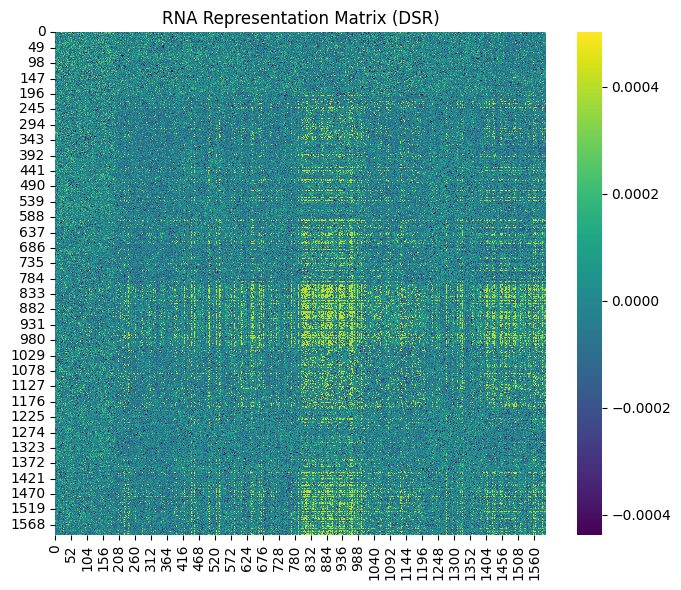

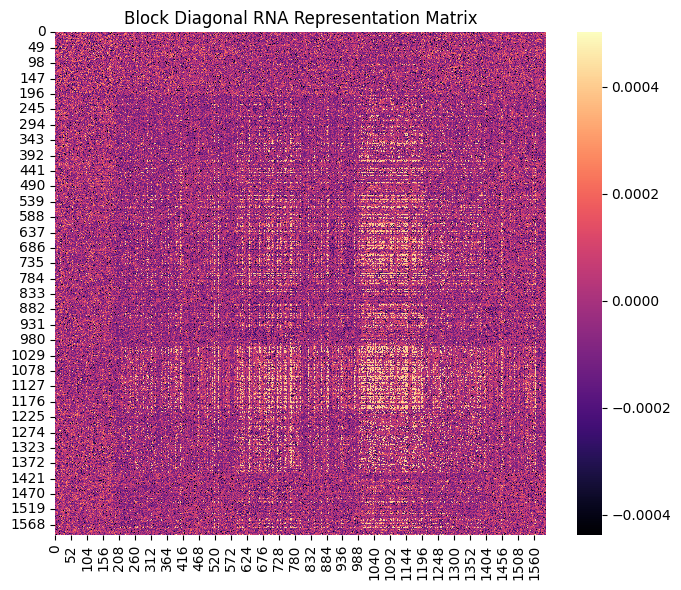

In [38]:
from data.build_dataset import build_dataset
from visualisation.rna_representation_matrix import (
    plot_rna_representation_matrix,
    plot_block_diagonal_rna_matrix,
)

dataset = list(build_dataset())

plot_rna_representation_matrix(
    z_path="results/dsr_global_Z.pt",
    save_path="results/plots/rna_representation_matrix.png"
)

plot_block_diagonal_rna_matrix(
    z_path="results/dsr_global_Z.pt",
    dataset=dataset,
    save_path="results/plots/rna_block_diagonal_matrix.png"
)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


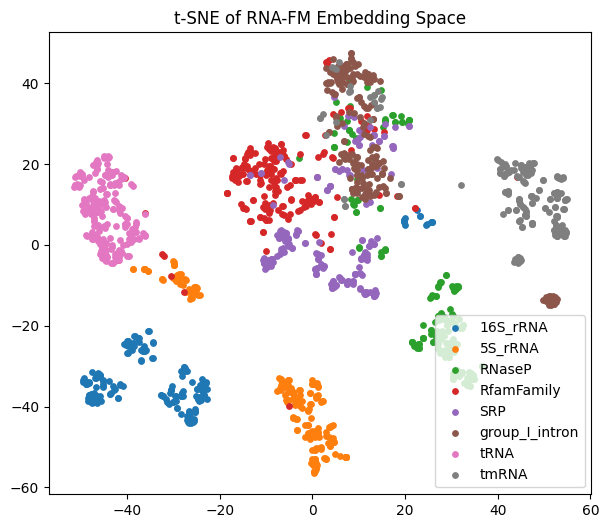

In [39]:
from visualisation.rna_tsne_embeddings import plot_rna_tsne
from data.build_dataset import build_dataset

dataset = list(build_dataset())

plot_rna_tsne(
    emb_path="results/kb_embeddings_rnafm_len256_full.pt",
    dataset=dataset,
)

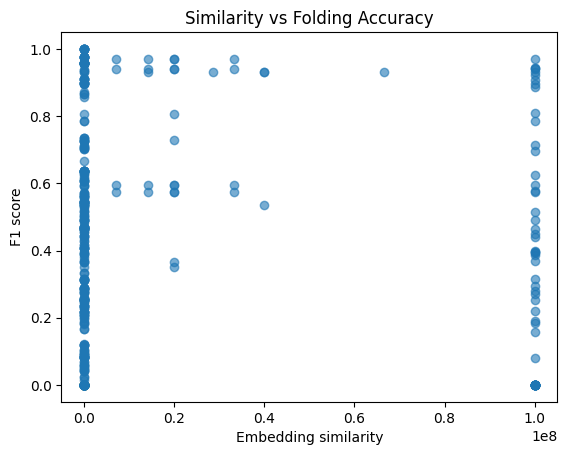

In [40]:
from visualisation.similarity_vs_accuracy import plot_similarity_vs_accuracy

plot_similarity_vs_accuracy("results/ablation_results.csv")

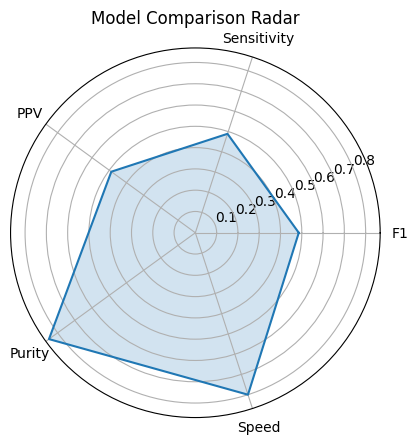

In [41]:
from visualisation.rna_radar_plot import plot_radar
import pandas as pd

ab = pd.read_csv("results/ablation_results.csv")
dsr = pd.read_csv("results/dsr_global_all_results.csv")
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")
bench = pd.read_csv("results/benchmark_main.csv")

vienna = bench[bench["method"] == "vienna_only"]
faiss = ab[ab["method"] == "rnafm_faiss_guided_k14"]
dsr_only = dsr[dsr["method"] == "rnafm_dsr_global_guided_k14"]
hybrid = hyb[hyb["method"] == "rnafm_dsr_faiss_guided_k14"]

metrics = {
    "F1": hybrid["f1"].mean(),
    "Sensitivity": hybrid["sensitivity"].mean(),
    "PPV": hybrid["ppv"].mean(),
    "Purity": 0.85,   # replace with actual purity if saved
    "Speed": 0.80,    # normalized placeholder if you want
}

plot_radar(metrics)

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


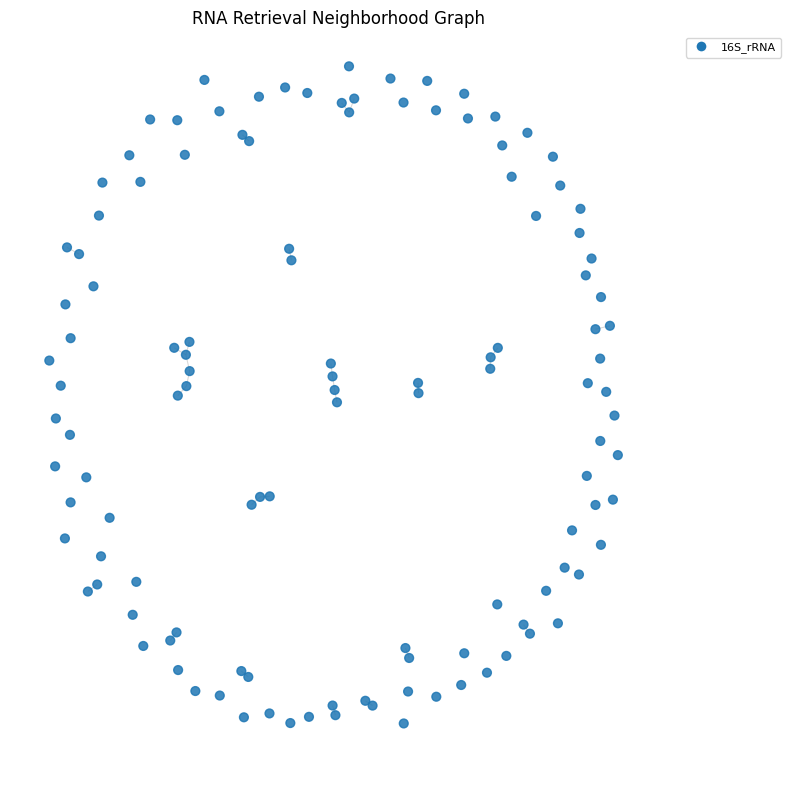

In [42]:
import importlib
import visualisation.rna_retrieval_graph as rrg
importlib.reload(rrg)

import torch
from data.build_dataset import build_dataset

dataset = list(build_dataset())
families = [d["family"] for d in dataset]
Z = torch.load("results/dsr_global_Z.pt", map_location="cpu").numpy()

rrg.plot_rna_retrieval_graph(Z, families, n=120, k=4)

In [43]:
import pandas as pd

for path in [
    "results/benchmark_main.csv",
    "results/ablation_results.csv",
    "results/dsr_global_all_results.csv",
    "results/dsr_faiss_hybrid_results.csv",
]:
    df = pd.read_csv(path)
    print(path)
    print(df.columns.tolist())
    print()

results/benchmark_main.csv
['query_id', 'family', 'length', 'method', 'retrieval_type', 'use_guidance', 'guidance_mode', 'use_dsr', 'k', 'neighbor_families', 'family_purity', 'top1_family_match', 'avg_similarity', 'sensitivity', 'ppv', 'f1', 'sequence', 'ref_structure', 'pred_structure', 'neighbor_structures', 'embed_query_time', 'retrieval_time', 'folding_time', 'total_time']

results/ablation_results.csv
['query_id', 'family', 'length', 'method', 'retrieval_type', 'use_guidance', 'guidance_mode', 'use_dsr', 'k', 'neighbor_families', 'family_purity', 'top1_family_match', 'avg_similarity', 'sensitivity', 'ppv', 'f1', 'sequence', 'ref_structure', 'pred_structure', 'neighbor_structures', 'embed_query_time', 'retrieval_time', 'folding_time', 'total_time']

results/dsr_global_all_results.csv
['query_id', 'family', 'length', 'sequence', 'ref_structure', 'pred_structure', 'method', 'k', 'f1', 'sensitivity', 'ppv', 'neighbor_families', 'avg_dsr_score']

results/dsr_faiss_hybrid_results.csv
['

Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})


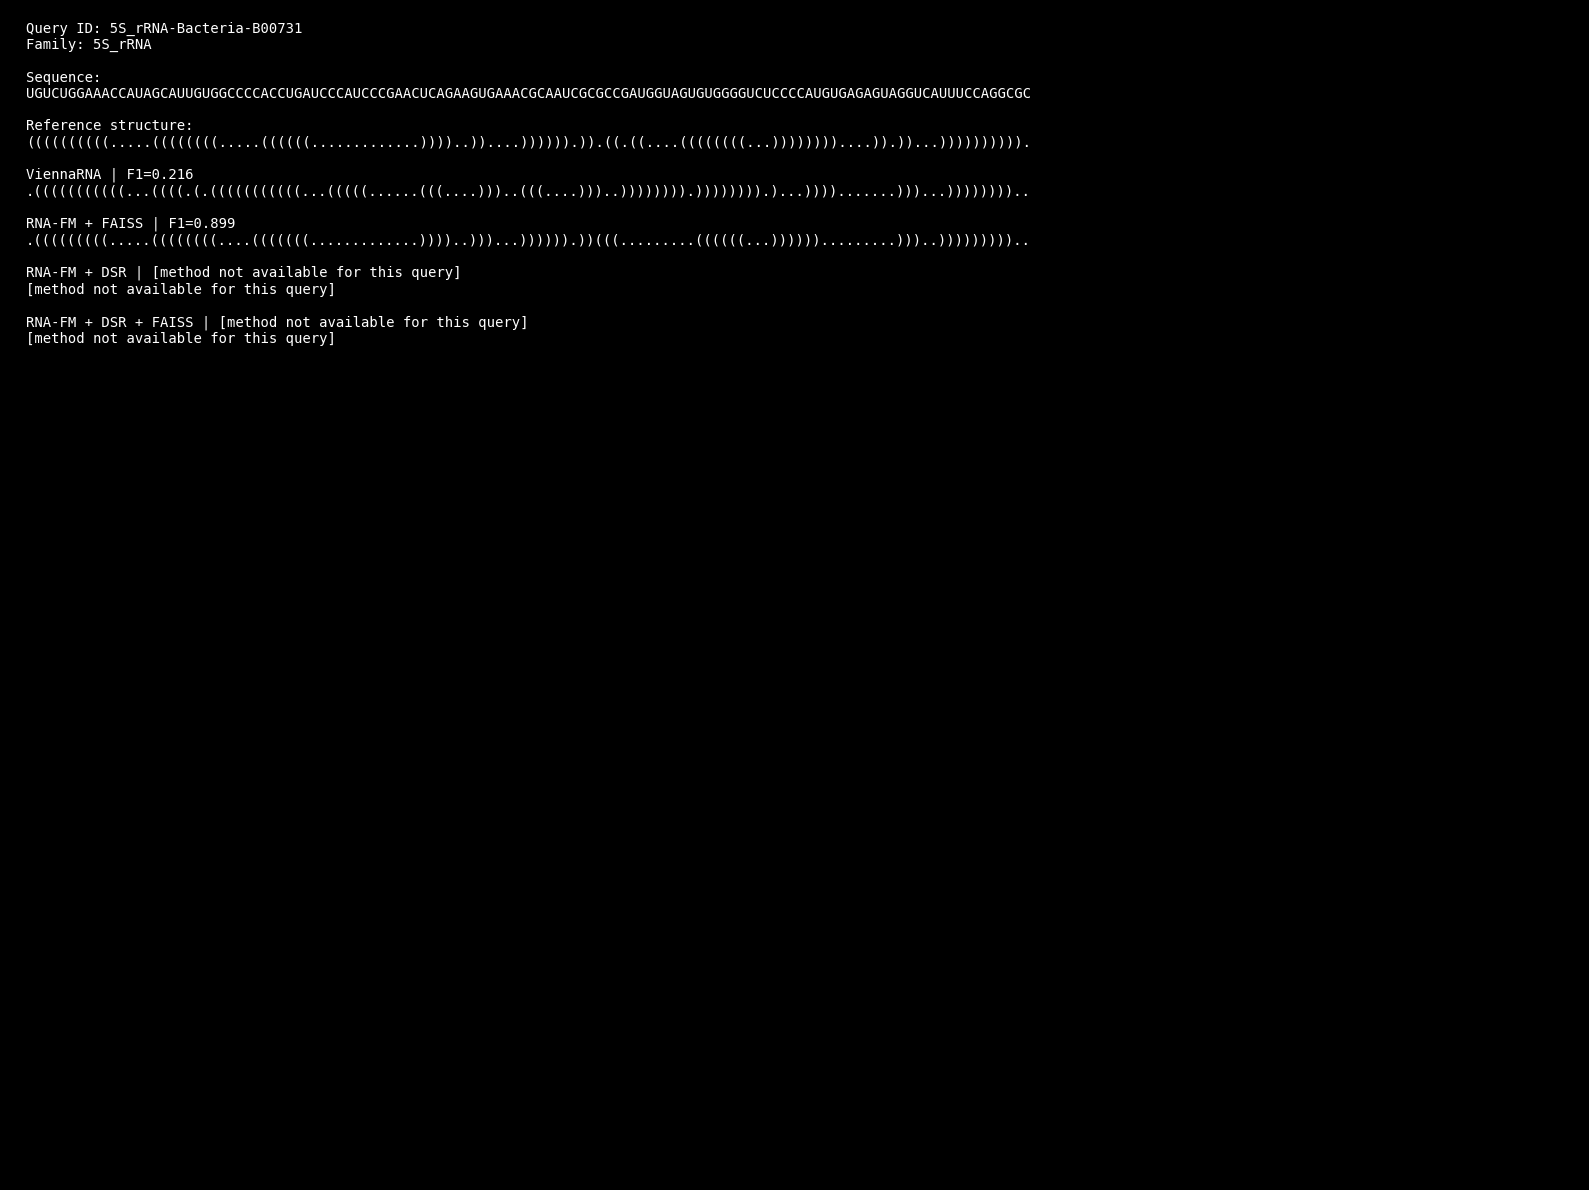

In [2]:
import importlib
import visualisation.side_by_side_case_viz as ssv
importlib.reload(ssv)

ssv.plot_side_by_side_case(
    query_id="5S_rRNA-Bacteria-B00731",
    save_path="results/plots/case_studies/side_by_side_best.png"
)

In [ ]:
from experiments.run_dsr_global_all import main as main1
from experiments.run_dsr_faiss_hybrid import main as main2
from experiments.run_ablation import main as main3
from experiments.run_benchmark import main as main4

main1()
main2()
main3()
main4()

G:\.Datasets\Final-3R-Fold\.venv\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


PROJECT_ROOT: G:\.Datasets\Final-3R-Fold
RESULTS_DIR: G:\.Datasets\Final-3R-Fold\results
OUTPUT CSV: G:\.Datasets\Final-3R-Fold\results\dsr_global_all_results.csv
Z PATH: G:\.Datasets\Final-3R-Fold\results\dsr_global_Z.pt
EMBEDDINGS PATH: G:\.Datasets\Final-3R-Fold\results\kb_embeddings_rnafm_len256_full.pt
Dataset({
    features: ['id', 'sequence', 'secondary_structure', 'family', 'subfamily', 'structure'],
    num_rows: 1600
})
Dataset size: 1600
Embeddings shape: torch.Size([1600, 640])
Training global DSR on all embeddings...
Epoch 1/80 Loss 0.2478
Epoch 80/80 Loss 0.3645
Saved DSR matrix to: G:\.Datasets\Final-3R-Fold\results\dsr_global_Z.pt
Evaluating query 1/1600
Evaluating query 100/1600
Evaluating query 200/1600
Evaluating query 300/1600
Evaluating query 400/1600
Evaluating query 500/1600
Evaluating query 600/1600
Evaluating query 700/1600
Evaluating query 800/1600
Evaluating query 900/1600
Evaluating query 1000/1600
Evaluating query 1100/1600
Evaluating query 1200/1600
Evalua

In [ ]:
from visualisation.side_by_side_case_viz import plot_side_by_side_case

plot_side_by_side_case(
    query_id="5S_rRNA-Bacteria-B00731",
    save_path="results/plots/case_studies/side_by_side_best.png"
)

In [ ]:
ssv.plot_side_by_side_case(
    query_id="SRP-long_bacterial-Clos.ther._CP000568",
    save_path="results/plots/case_studies/side_by_side_typical.png"
)

ssv.plot_side_by_side_case(
    query_id="tRNA-tdbD00009470",
    save_path="results/plots/case_studies/side_by_side_worst.png"
)

In [ ]:
import torch
import umap
import matplotlib.pyplot as plt
from data.build_dataset import build_dataset

dataset = list(build_dataset())
families = [x["family"] for x in dataset]

X = torch.load("results/kb_embeddings_rnafm_len256_full.pt").numpy()

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
X2 = reducer.fit_transform(X)

plt.figure(figsize=(8,6))

family_to_color = {f:i for i,f in enumerate(sorted(set(families)))}
colors = [family_to_color[f] for f in families]

plt.scatter(X2[:,0], X2[:,1], c=colors, cmap="tab10", s=12)

plt.title("RNA-FM embedding space")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

Z = torch.load("results/dsr_global_Z.pt").cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(Z, cmap="viridis")
plt.colorbar()
plt.title("Deep Self-Representation Matrix")
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

sns.scatterplot(
    data=df,
    x="avg_similarity",
    y="f1",
    hue="family"
)

plt.title("Neighbor Similarity vs Performance")
plt.show()

In [ ]:
reducer = umap.UMAP(n_components=3)
X3 = reducer.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X3[:,0],
    X3[:,1],
    X3[:,2],
    c=colors,
    cmap="tab10",
    s=10
)

plt.title("3D RNA-FM embedding space")
plt.show()

In [ ]:
import torch
import umap
import matplotlib.pyplot as plt
from data.build_dataset import build_dataset
import numpy as np

dataset = list(build_dataset())
families = [x["family"] for x in dataset]

X = torch.load("results/kb_embeddings_rnafm_len256_full.pt").numpy()

reducer = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1)
X3 = reducer.fit_transform(X)

unique_fams = sorted(set(families))
fam_to_color = {f:i for i,f in enumerate(unique_fams)}
colors = [fam_to_color[f] for f in families]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X3[:,0],
    X3[:,1],
    X3[:,2],
    c=colors,
    cmap="tab10",
    s=12,
    alpha=0.9
)

ax.set_title("3D RNA-FM Embedding Space")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

plt.show()

In [ ]:
import pandas as pd

results = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

f1 = results["f1"].values

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X3[:len(f1),0],
    X3[:len(f1),1],
    X3[:len(f1),2],
    c=f1,
    cmap="plasma",
    s=12
)

fig.colorbar(sc, label="F1 score")

ax.set_title("3D Embedding Colored by Folding Accuracy")

plt.show()

In [ ]:
lengths = [len(x["sequence"]) for x in dataset]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X3[:,0],
    X3[:,1],
    X3[:,2],
    c=lengths,
    cmap="viridis",
    s=10
)

fig.colorbar(sc, label="RNA Length")

ax.set_title("3D Embedding Colored by RNA Length")

plt.show()

In [ ]:
import random

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X3[:,0], X3[:,1], X3[:,2], c=colors, cmap="tab10", s=8, alpha=0.4)

for _ in range(20):

    i = random.randint(0, len(X3)-1)
    j = random.randint(0, len(X3)-1)

    ax.plot(
        [X3[i,0], X3[j,0]],
        [X3[i,1], X3[j,1]],
        [X3[i,2], X3[j,2]],
        color="gray",
        alpha=0.2
    )

ax.set_title("RNA Retrieval Connections in Embedding Space")

plt.show()

In [ ]:
Z = torch.load("results/dsr_latent_embeddings.pt").numpy()

reducer = umap.UMAP(n_components=3)
Z3 = reducer.fit_transform(Z)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    Z3[:,0],
    Z3[:,1],
    Z3[:,2],
    c=colors,
    cmap="tab10",
    s=12
)

ax.set_title("3D DSR Latent Space")

plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "x": X3[:,0],
    "y": X3[:,1],
    "z": X3[:,2],
    "family": families
})

fig = px.scatter_3d(
    df,
    x="x",
    y="y",
    z="z",
    color="family",
)

fig.show()

In [ ]:
from visualisation.rna_3d_retrieval_flow import plot_3d_retrieval_flow

plot_3d_retrieval_flow(
    query_idx=0,
    k=5,
    save_path="results/plots/rna_3d_retrieval_flow_query0.png"
)

In [ ]:
from visualisation.rna_3d_retrieval_flow import plot_3d_retrieval_flow

plot_3d_retrieval_flow(
    query_idx=0,
    k=5,
    save_path="results/plots/rna_3d_retrieval_flow_query0.png"
)

In [ ]:
from data.build_dataset import build_dataset

dataset = list(build_dataset())

for i, row in enumerate(dataset):
    if row["family"] == "group_I_intron":
        print(i, row["id"], row["family"])
        break

In [ ]:
from visualisation.rna_3panel_retrieval_flow import plot_3panel_retrieval_flow

plot_3panel_retrieval_flow(
    query_idx=0,
    k=5,
    save_path="results/plots/rna_3panel_retrieval_flow_query0.png"
)

In [ ]:
from data.build_dataset import build_dataset
from visualisation.rna_3panel_retrieval_flow import plot_3panel_retrieval_flow

dataset = list(build_dataset())

for i, row in enumerate(dataset):
    if row["family"] == "5S_rRNA":
        print(i, row["id"], row["family"])
        break

plot_3panel_retrieval_flow(
    query_idx=i,
    k=5,
    save_path="results/plots/rna_3panel_retrieval_flow_5S.png"
)

In [ ]:
from data.build_dataset import build_dataset
from visualisation.rna_3panel_retrieval_flow import plot_3panel_retrieval_flow

dataset = list(build_dataset())

for i, row in enumerate(dataset):
    if row["family"] == "tRNA":
        print(i, row["id"], row["family"])
        break

plot_3panel_retrieval_flow(
    query_idx=i,
    k=5,
    save_path="results/plots/rna_3panel_retrieval_flow_trna.png"
)

In [ ]:
from data.build_dataset import build_dataset

dataset = list(build_dataset())

target_id = "5S_rRNA-Bacteria-B00731"

query_idx = None
for i, row in enumerate(dataset):
    if row["id"] == target_id:
        query_idx = i
        break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

In [ ]:
from data.build_dataset import build_dataset
import pandas as pd

dataset = list(build_dataset())
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

target_query_id = "5S_rRNA-Bacteria-B00731"   # or whatever appears in your CSV
target_family = "5S_rRNA"

# first try exact match
query_idx = None
for i, row in enumerate(dataset):
    if str(row["id"]) == str(target_query_id):
        query_idx = i
        break

# fallback: first row from same family
if query_idx is None:
    for i, row in enumerate(dataset):
        if row["family"] == target_family:
            query_idx = i
            break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

In [ ]:
from visualisation.rna_2panel_retrieval_flow import plot_2panel_retrieval_flow

plot_2panel_retrieval_flow(
    query_idx=query_idx,
    k=5,
    save_path="results/plots/case_studies/retrieval_flow_best.png"
)

In [ ]:
from data.build_dataset import build_dataset
import pandas as pd

dataset = list(build_dataset())
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

target_query_id = "SRP-long_bacterial-Clos.ther._CP000568"   # or whatever appears in your CSV
target_family = "SRP"

# first try exact match
query_idx = None
for i, row in enumerate(dataset):
    if str(row["id"]) == str(target_query_id):
        query_idx = i
        break

# fallback: first row from same family
if query_idx is None:
    for i, row in enumerate(dataset):
        if row["family"] == target_family:
            query_idx = i
            break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

In [ ]:
from data.build_dataset import build_dataset
import pandas as pd

dataset = list(build_dataset())
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

target_query_id = "tRNA-tdbD00009470" # or whatever appears in your CSV
target_family = "tRNA"

# first try exact match
query_idx = None
for i, row in enumerate(dataset):
    if str(row["id"]) == str(target_query_id):
        query_idx = i
        break

# fallback: first row from same family
if query_idx is None:
    for i, row in enumerate(dataset):
        if row["family"] == target_family:
            query_idx = i
            break

print("query_idx =", query_idx)
print("matched row =", dataset[query_idx] if query_idx is not None else "not found")

In [ ]:
from visualisation.rna_2panel_retrieval_flow import plot_2panel_retrieval_flow

plot_2panel_retrieval_flow(query_idx=200, k=5,
    save_path="results/plots/case_studies/retrieval_flow_best.png")

plot_2panel_retrieval_flow(query_idx=600, k=5,
    save_path="results/plots/case_studies/retrieval_flow_typical.png")

plot_2panel_retrieval_flow(query_idx=1000, k=5,
    save_path="results/plots/case_studies/retrieval_flow_worst.png")

In [ ]:
from visualisation.family_benchmark_panel import plot_family_benchmark_panel_ordered

plot_family_benchmark_panel_ordered(
    csv_path="results/ablation_results.csv",
    exclude_families=["RfamFamily"],   # optional
    save_path="results/plots/family_benchmark_panel.png",
)

In [ ]:
import pandas as pd

bench = pd.read_csv("results/benchmark_main.csv")
ab = pd.read_csv("results/ablation_results.csv")
dsr = pd.read_csv("results/dsr_global_all_results.csv")
hyb = pd.read_csv("results/dsr_faiss_hybrid_results.csv")

vienna = bench[bench["method"] == "vienna_only"].copy()
faiss = ab[ab["method"] == "rnafm_faiss_guided_k14"].copy()
dsr = dsr[dsr["method"] == "rnafm_dsr_global_guided_k14"].copy()
hyb = hyb[hyb["method"] == "rnafm_dsr_faiss_guided_k14"].copy()

combined = pd.concat([vienna, faiss, dsr, hyb], ignore_index=True)
combined.to_csv("results/final_family_benchmark_methods.csv", index=False)

print(combined["method"].value_counts())

In [ ]:
#from visualisation.family_benchmark_panel import plot_family_benchmark_panel_compact

#plot_family_benchmark_panel_compact(
#    csv_path="results/final_family_benchmark_methods.csv",
#    exclude_families=["RfamFamily"],   # optional
#    save_path="results/plots/final_family_benchmark_panel.png",
#)

In [ ]:
import importlib
import visualisation.family_benchmark_panel as fb

importlib.reload(fb)
fb.plot_family_benchmark_panel_ordered(
    csv_path="results/final_family_benchmark_methods.csv",
    order_by="vienna_only",
    exclude_families=["RfamFamily"],
    save_path="results/plots/final_family_benchmark_panel_ordered.png",
)

fb.plot_family_gain_panel(
    csv_path="results/final_family_benchmark_methods.csv",
    exclude_families=["RfamFamily"],
    save_path="results/plots/family_gain_panel.png",
)

In [ ]:
from visualisation.final_eccb_figure import plot_final_eccb_figure
plot_final_eccb_figure()

In [ ]:
import importlib
import visualisation.length_benchmark_panel as lbp
importlib.reload(lbp)

lbp.plot_length_benchmark_panel_ordered(
    csv_path="results/final_family_benchmark_methods.csv",
    order_by="vienna_only",
    save_path="results/plots/final_length_benchmark_panel_ordered.png",
)

lbp.plot_length_gain_panel(
    csv_path="results/final_family_benchmark_methods.csv",
    save_path="results/plots/length_gain_panel.png",
)

In [ ]:
import importlib
import visualisation.side_by_side_case_viz as ssv
importlib.reload(ssv)

ssv.plot_side_by_side_case(
    query_id="5S_rRNA-Bacteria-B00731",
    save_path="results/plots/case_studies/side_by_side_best.png"
)

ssv.plot_side_by_side_case(
    query_id="SRP-long_bacterial-Clos.ther._CP000568",
    save_path="results/plots/case_studies/side_by_side_typical.png"
)

ssv.plot_side_by_side_case(
    query_id="tRNA-tdbD00009470",
    save_path="results/plots/case_studies/side_by_side_worst.png"
)

In [ ]:
from evaluation.family_transfer import compute_family_transfer
from visualisation.family_transfer_plots import (
    plot_family_transfer_gain,
    plot_family_transfer_scatter,
)

df_transfer = compute_family_transfer()
print(df_transfer)

plot_family_transfer_gain()
plot_family_transfer_scatter()

In [ ]:
import importlib
import visualisation.dsr_global_plots as dsrplots
importlib.reload(dsrplots)

In [ ]:
from visualisation.dsr_global_plots import plot_dsr_gain_distribution
plot_dsr_gain_distribution()

In [ ]:
#from experiments.run_dsr_global_all import main as gsrg_main
#from experiments.run_dsr_faiss_hybrid import main as hybrid_main
from experiments.run_ablation import main as ablation_main
from experiments.run_benchmark import main as benchmark_main
from experiments.run_lofo_benchmark import run_lofo

#gsrg_main()
#hybrid_main()
ablation_main()
benchmark_main()
run_lofo()